In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from package.RankAMIP.logistic import run_logistic_regression
from package.RankAMIP.data_script import make_BT_design_matrix
from package.RankAMIP.logistic import LogisticAMIP
from package.RankAMIP.logistic import find_closest_matchups
from package.RankAMIP.logistic import isRankingRobust
from package.RankAMIP.plot_util import *

### Is the NBA Tournament Data Robust?

### Load Data.

In [2]:
# Import
df = pd.read_csv('/Users/JennyH/Desktop/IsRankingRobust/results/nbaallelo.csv')

In [3]:
# Create team_won column based on game_result
df['team_won'] = (df['game_result'] == 'W').astype(int)
df.head()

,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,...,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes,team_won
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,...,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN,0
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,...,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN,1
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,...,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN,1
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,...,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN,0
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,...,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN,0


In [17]:
df['game_result'].value_counts()

L    63157
W    63157
Name: game_result, dtype: int64

In [5]:
# Count unique teams in the dataset
print(f"Number of unique teams: {len(df['team_id'].unique())}")
df['team_id'].unique()

Number of unique teams: 104


array(['TRH', 'NYK', 'CHS', 'DTF', 'WSC', 'BOS', 'PRO', 'PIT', 'STB',
       'CLR', 'PHW', 'BLB', 'INJ', 'FTW', 'MNL', 'ROC', 'TRI', 'DNN',
       'INO', 'SHE', 'WAT', 'AND', 'SYR', 'MLH', 'STL', 'DET', 'CIN',
       'LAL', 'CHP', 'CHZ', 'SFW', 'BAL', 'PHI', 'CHI', 'SEA', 'OAK',
       'ANA', 'SDR', 'KEN', 'INA', 'DNR', 'DLC', 'HSM', 'NOB', 'MNM',
       'NJA', 'PTP', 'ATL', 'MIL', 'PHO', 'NYA', 'MMF', 'MNP', 'LAS',
       'CAR', 'WSA', 'BUF', 'CLE', 'UTS', 'FLO', 'PTC', 'POR', 'VIR',
       'TEX', 'MMP', 'HOU', 'GSW', 'KCO', 'MMT', 'SDA', 'CAP', 'SAA',
       'NOJ', 'DNA', 'SSL', 'MMS', 'WSB', 'KCK', 'SDS', 'IND', 'NYN',
       'DEN', 'SAS', 'NJN', 'SDC', 'UTA', 'DAL', 'LAC', 'SAC', 'CHH',
       'MIA', 'MIN', 'ORL', 'VAN', 'TOR', 'WAS', 'MEM', 'NOH', 'CHA',
       'NOK', 'OKC', 'BRK', 'NOP', 'CHO'], dtype=object)

In [6]:
# drop rows in df with df['winner_tie'] == 1
rawBT = df[['team_id', 'opp_id', 'team_won']]
rawBT.head()

,team_id,opp_id,team_won
0,TRH,NYK,0
1,NYK,TRH,1
2,CHS,NYK,1
3,NYK,CHS,0
4,DTF,WSC,0


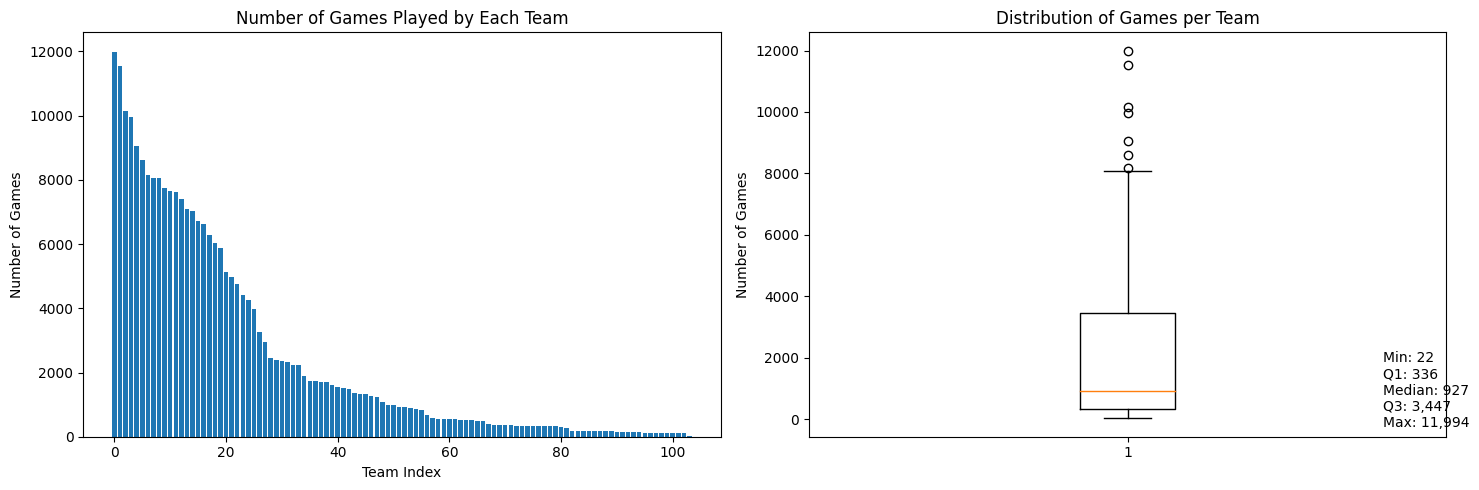

In [7]:
# Count games per team
team_games = pd.concat([rawBT['team_id'], rawBT['opp_id']]).value_counts()

# Calculate 5-number summary
summary = {
    'Min': team_games.min(),
    'Q1': team_games.quantile(0.25),
    'Median': team_games.median(),
    'Q3': team_games.quantile(0.75),
    'Max': team_games.max()
}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

# Bar plot
ax1.bar(range(len(team_games)), team_games.values)
ax1.set_title('Number of Games Played by Each Team')
ax1.set_xlabel('Team Index')
ax1.set_ylabel('Number of Games')

# Box plot
ax2.boxplot(team_games.values)
ax2.set_title('Distribution of Games per Team')
ax2.set_ylabel('Number of Games')

# Add text with 5-number summary
summary_text = '\n'.join([f'{k}: {v:,.0f}' for k,v in summary.items()])
ax2.text(1.4, summary['Median'], summary_text, verticalalignment='center')

plt.tight_layout()


To avoid ill-conditioning (logistic regression non-convergence) we will focus our analysis on the top 50 teams in the NBA that play the most games.

In [8]:
# Count games per team
team_games = pd.concat([rawBT['team_id'], rawBT['opp_id']]).value_counts()

# Get top 50 teams by number of games
top_50_teams = team_games.nlargest(50).index

# Filter rawBT to only include those teams
rawBT_top50 = rawBT[
    (rawBT['team_id'].isin(top_50_teams)) & 
    (rawBT['opp_id'].isin(top_50_teams))
]
rawBT_top50

,team_id,opp_id,team_won
102,PHW,BOS,1
103,BOS,PHW,0
122,NYK,PHW,1
123,PHW,NYK,0
148,NYK,PHW,0
...,...,...,...
126309,CLE,GSW,0
126310,GSW,CLE,1
126311,CLE,GSW,0
126312,CLE,GSW,0


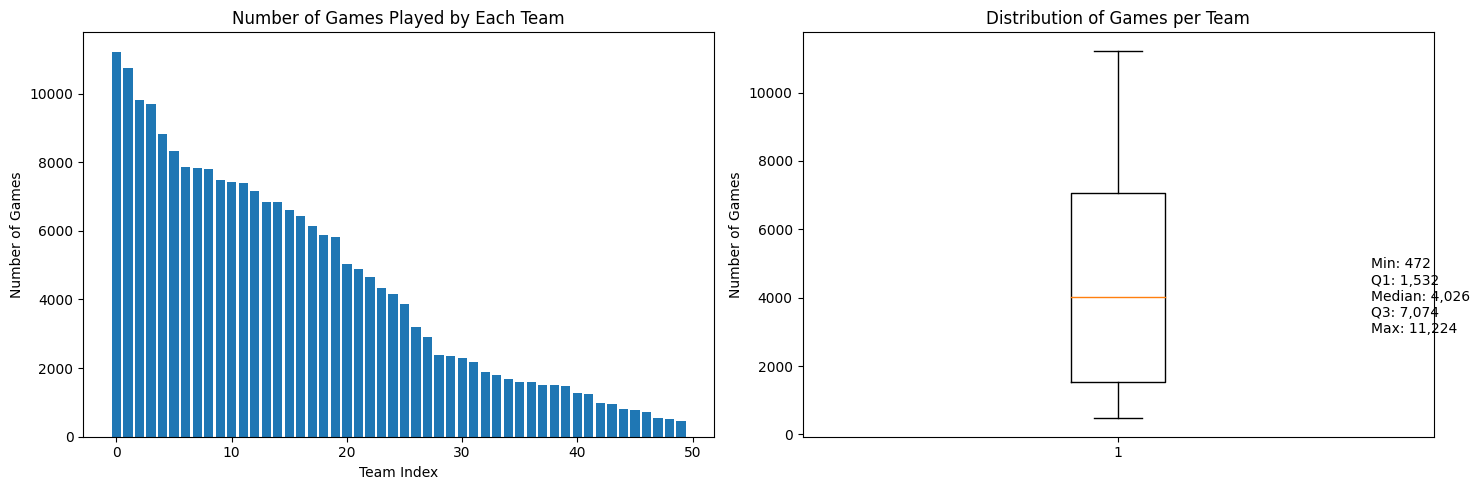

In [9]:
# Count games per team
team_games = pd.concat([rawBT_top50['team_id'], rawBT_top50['opp_id']]).value_counts()

# Calculate 5-number summary
summary = {
    'Min': team_games.min(),
    'Q1': team_games.quantile(0.25),
    'Median': team_games.median(),
    'Q3': team_games.quantile(0.75),
    'Max': team_games.max()
}

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

# Bar plot
ax1.bar(range(len(team_games)), team_games.values)
ax1.set_title('Number of Games Played by Each Team')
ax1.set_xlabel('Team Index')
ax1.set_ylabel('Number of Games')

# Box plot
ax2.boxplot(team_games.values)
ax2.set_title('Distribution of Games per Team')
ax2.set_ylabel('Number of Games')

# Add text with 5-number summary
summary_text = '\n'.join([f'{k}: {v:,.0f}' for k,v in summary.items()])
ax2.text(1.4, summary['Median'], summary_text, verticalalignment='center')

plt.tight_layout()

There are a total of 109,892 matchups between the top 50 teams.

In [18]:
# make weighted design matrix for BT.
X, y, player_to_id = make_BT_design_matrix(rawBT_top50, weight_tie = False)
X.shape, y.shape

((109892, 49), (109892,))

## Uniform Data-dropping

In [15]:
# compute BT scores.
model_full = run_logistic_regression(X, y)

# prepend model 0, the reference model, which has score 0.
bt_scores = np.insert(model_full.coef_[0], 0, 0)

# combine bt_scores with player names
id_to_player = {v: k for k, v in player_to_id.items()}
bt_scores_with_names = {id_to_player[i]: score for i, score in enumerate(bt_scores)}

# Determine the original top model
top_model_original = max(bt_scores_with_names.items(), key=lambda x: x[1])[0]
print("original top 5 models: ", dict(sorted(bt_scores_with_names.items(), key=lambda x: x[1], reverse=True)[:5]))

num_trials = 100
num_agree = 0

for trial in range(num_trials):
    indices = np.random.choice(X.shape[0], size=int(X.shape[0]*0.01), replace=False)
    X_dropped = np.delete(X, indices, axis=0)
    y_dropped = np.delete(y, indices, axis=0)

    model_dropped = run_logistic_regression(X_dropped, y_dropped)
    bt_scores_dropped = np.insert(model_dropped.coef_[0], 0, 0)
    bt_scores_with_names_dropped = {id_to_player[i]: score for i, score in enumerate(bt_scores_dropped)}
    top_model_dropped = max(bt_scores_with_names_dropped.items(), key=lambda x: x[1])[0]
    if top_model_dropped == top_model_original:
        num_agree += 1

    # Optional: Show some progress every 10 iterations
    if (trial+1) % 10 == 0:
        print(f"Completed {trial+1} trials...")

print(f"Fraction of times top-ranked model stays the same after dropping 1% of the data: {num_agree/num_trials:.2f}")

original top 5 models:  {'LAL': 0.399499451861836, 'SAS': 0.345254162085515, 'OKC': 0.32049088491710437, 'UTS': 0.3119035384574139, 'BOS': 0.2765575946061137}
Completed 10 trials...
Completed 20 trials...
Completed 30 trials...
Completed 40 trials...
Completed 50 trials...
Completed 60 trials...
Completed 70 trials...
Completed 80 trials...
Completed 90 trials...
Completed 100 trials...
Fraction of times top-ranked model stays the same after dropping 1% of the data: 1.00


### Robustness of Bootstrap Confidence Interval Rankings


In [23]:
#### Format data correctly.
rawBT.head()
# rename team_id to model_a and opp_id to model_b
rawBT = rawBT.rename(columns={'team_id': 'model_a', 'opp_id': 'model_b'})
rawBT.head()


,model_a,model_b,team_won
0,TRH,NYK,0
1,NYK,TRH,1
2,CHS,NYK,1
3,NYK,CHS,0
4,DTF,WSC,0


In [27]:
# add a column called winner that is model_a if team_won == 0, model_b if team_won == 1
def determine_winner(row):
    if row['team_won'] == 1:
        return row['model_a']
    else:
        return row['model_b']

rawBT['winner'] = rawBT.apply(determine_winner, axis=1)

In [28]:
rawBT

,model_a,model_b,team_won,winner
0,TRH,NYK,0,NYK
1,NYK,TRH,1,NYK
2,CHS,NYK,1,CHS
3,NYK,CHS,0,CHS
4,DTF,WSC,0,WSC
...,...,...,...,...
126309,CLE,GSW,0,GSW
126310,GSW,CLE,1,GSW
126311,CLE,GSW,0,GSW
126312,CLE,GSW,0,GSW


In [29]:
import importlib
import compute_CIs
importlib.reload(compute_CIs)

<module 'compute_CIs' from '/Users/JennyH/Desktop/IsRankingRobust/compute_CIs.py'>

In [ ]:
BOOTSTRAP_ROUNDS = 100
### Obtain Bootstrap Confidence Intervals.
np.random.seed(42)
bootstrap_elo_lu = compute_CIs.get_bootstrap_result(rawBT, compute_CIs.compute_mle_elo, BOOTSTRAP_ROUNDS)
bootstrap_elo_lu.describe()
# show the 95% confidence interval for each model
ci_lower = bootstrap_elo_lu.quantile(0.025)
ci_upper = bootstrap_elo_lu.quantile(0.975)
ci_med = bootstrap_elo_lu.median()
ci_df = pd.DataFrame({
    "2.5%": ci_lower,
    "Median": ci_med,
    "97.5%": ci_upper
})
ci_df

In [11]:
# save X and y as a .pkl file.
# import pickle
# with open('results/X_y_top50.pkl', 'wb') as f:
#     pickle.dump((X, y), f)

# read in X and y from .pkl file
import pickle
with open('results/X_y_top50.pkl', 'rb') as f:
    X, y = pickle.load(f)


In [12]:
id_to_player = {v: k for k, v in player_to_id.items()}
id_to_player

{0: 'PHW',
 1: 'BOS',
 2: 'NYK',
 3: 'FTW',
 4: 'MNL',
 5: 'ROC',
 6: 'SYR',
 7: 'STL',
 8: 'DET',
 9: 'CIN',
 10: 'LAL',
 11: 'SFW',
 12: 'BAL',
 13: 'PHI',
 14: 'CHI',
 15: 'SEA',
 16: 'KEN',
 17: 'INA',
 18: 'DNR',
 19: 'ATL',
 20: 'MIL',
 21: 'PHO',
 22: 'NYA',
 23: 'BUF',
 24: 'CLE',
 25: 'UTS',
 26: 'POR',
 27: 'VIR',
 28: 'HOU',
 29: 'GSW',
 30: 'WSB',
 31: 'KCK',
 32: 'IND',
 33: 'DEN',
 34: 'SAS',
 35: 'NJN',
 36: 'UTA',
 37: 'DAL',
 38: 'LAC',
 39: 'SAC',
 40: 'CHH',
 41: 'MIA',
 42: 'MIN',
 43: 'ORL',
 44: 'TOR',
 45: 'WAS',
 46: 'MEM',
 47: 'NOH',
 48: 'CHA',
 49: 'OKC'}

In [13]:
# Poorly conditioned matrix has very large condition number
cond_number = np.linalg.cond(X.T @ X)
print(f"Condition number: {cond_number}") # If cond_number > 1e12, the matrix is ill-conditioned

Condition number: 1.7788786157406896e+17


#### Run Top-k Robustness Check.

In [14]:
# read in X and y from .pkl file
import pickle
with open('results/X_y_top50.pkl', 'rb') as f:
    X, y = pickle.load(f)

ks = [1]
results = {}
for k in ks:
    alphaN = 1
    chatbotA = -1
    while chatbotA == -1:
        chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices = isRankingRobust(k, alphaN, X, y, weighted = False)
        results[(k, alphaN)] = (chatbotA, chatbotB, chatbotOriginalBetaDiff, chatNewBetaDiff, chatNewBetaDiffAMIP, chatIndices)
        alphaN += 1
        print(f"alphaN: {alphaN}")

KeyboardInterrupt: 

In [ ]:
# find the (k, alpha N) pairs that are non-robust.
results_nonrobust = {k: v for k, v in results.items() if v[0] != -1}
results_nonrobust

{(1, 9): (9,
  24,
  0.08759591340441242,
  0.042376638082141205,
  -0.007635558957674551,
  array([14523, 18818, 14382, 14383, 20485, 20484, 19716, 14522, 17659]))}

In [ ]:
# read in the non-robustness results.
import pickle
with open('results/nba_nonrobustness_results.pkl', 'rb') as f:
    results_nonrobust = pickle.load(f)

In [ ]:
results_nonrobust

{(1, 17): (9,
  24,
  0.08759591340442208,
  -0.0004388275103568984,
  array([18819, 19717, 18818, 19762, 14523, 19763, 14522, 20900, 22132,
         22133, 18305, 15756, 14383, 18304, 14382, 19716, 20135])),
 (3, 2): (48,
  24,
  0.008587346459690448,
  -0.001249610397564771,
  array([19716, 20134])),
 (5, 12): (24,
  15,
  0.06773798441073409,
  -0.0026610689057776082,
  array([15424, 15048, 14959, 14958, 20334, 20335, 16081, 14435, 21645,
         21644, 15425, 15049]))}

In [ ]:
17 / X.shape[0]

0.00015469733920576566

The NBA results are quite non-robust as well; perhaps the top teams don't actually differ too much in skill-level (super possible, given the stochasticity in vetting top players in the NBA)? perhaps this is a property inherent to the BT model?

Plot The BT-scores of the top 20 teams.

In [ ]:
rankings = return_rankings_list(X, y, results, 1, 2, player_to_id)

In [ ]:
# plot top-20 models on full chatbot arena.
filename_to_save = 'fig/top50_nba.png'
plot_title = 'Team Rankings in NBA'
plot_bt_scores(X, y, rankings, alphaN, 50, plot_title, filename_to_save)

#### Below, we inspect the ranking flip between the first- and second-place models.

17 evals were dropped to flip team 10 and 25.

These teams were:
('gpt-4-0125-preview', 0: 'gpt-4-1106-preview')

In [ ]:
id_to_player = {v: k for k, v in player_to_id.items()}
id_to_player[10], id_to_player[25]

('LAL', 'UTS')

In [ ]:
rawBT_top50.head()

,team_id,opp_id,team_won
102,PHW,BOS,1
103,BOS,PHW,0
122,NYK,PHW,1
123,PHW,NYK,0
148,NYK,PHW,0


In [ ]:
## Count number of games between the two teams that changed rankings.
is_LAL_UTS = (
    (rawBT_top50['team_id'].str.contains('LAL') & rawBT_top50['opp_id'].str.contains('UTS')) |
    (rawBT_top50['team_id'].str.contains('UTS') & rawBT_top50['opp_id'].str.contains('LAL'))
)

num_LAL_UTS = rawBT_top50[is_LAL_UTS].shape[0]
print("Number of games between LAL and UTS: ", num_LAL_UTS)

Number of games between LAL and UTS:  0


Interestingly, we get a case where the teams that flipped rankings were never in head-to-head matchup!

In [ ]:
# Count games between UTS and all other teams
all_teams = set(rawBT_top50['team_id'].unique()) | set(rawBT_top50['opp_id'].unique())
all_teams.remove('UTS')  # Remove UTS since we don't want to count UTS vs UTS

games_with_uts = []
for team in sorted(all_teams):
    is_UTS_team = (
        (rawBT_top50['team_id'] == 'UTS') & (rawBT_top50['opp_id'] == team) |
        (rawBT_top50['team_id'] == team) & (rawBT_top50['opp_id'] == 'UTS')
    )
    num_games = rawBT_top50[is_UTS_team].shape[0]
    if num_games > 0:  # Only show teams with games against UTS
        games_with_uts.append((team, num_games))

print("Number of games UTS played against each team:")
for team, count in sorted(games_with_uts, key=lambda x: x[1], reverse=True):
    print(f"UTS vs {team}: {count} games")

Number of games UTS played against each team:
UTS vs INA: 172 games
UTS vs DNR: 92 games
UTS vs KEN: 92 games
UTS vs NYA: 88 games
UTS vs VIR: 76 games


In [ ]:
# model pairs (sorted to group symmetric pairs)
rawBT_top50['player_pair'] = rawBT_top50.apply(lambda row: tuple(sorted([row['team_id'], row['opp_id']])), axis=1)
rawBT_top50['player_pair']

/var/folders/d0/9cwd6hsd1jx46dktk5_bn85c0000gn/T/ipykernel_79976/3161923905.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rawBT_top50['player_pair'] = rawBT_top50.apply(lambda row: tuple(sorted([row['team_id'], row['opp_id']])), axis=1)


102       (BOS, PHW)
103       (BOS, PHW)
122       (NYK, PHW)
123       (NYK, PHW)
148       (NYK, PHW)
             ...    
126309    (CLE, GSW)
126310    (CLE, GSW)
126311    (CLE, GSW)
126312    (CLE, GSW)
126313    (CLE, GSW)
Name: player_pair, Length: 109892, dtype: object

In [ ]:
# Count number of games per model pair
pair_counts = rawBT_top50['player_pair'].value_counts()

# Compute average
average_games_per_pair = pair_counts.mean()
print("Average number of games per team pair:", average_games_per_pair)

Average number of games per team pair: 165.00300300300302
